GIF saved successfully: six_mathematical_functions.gif


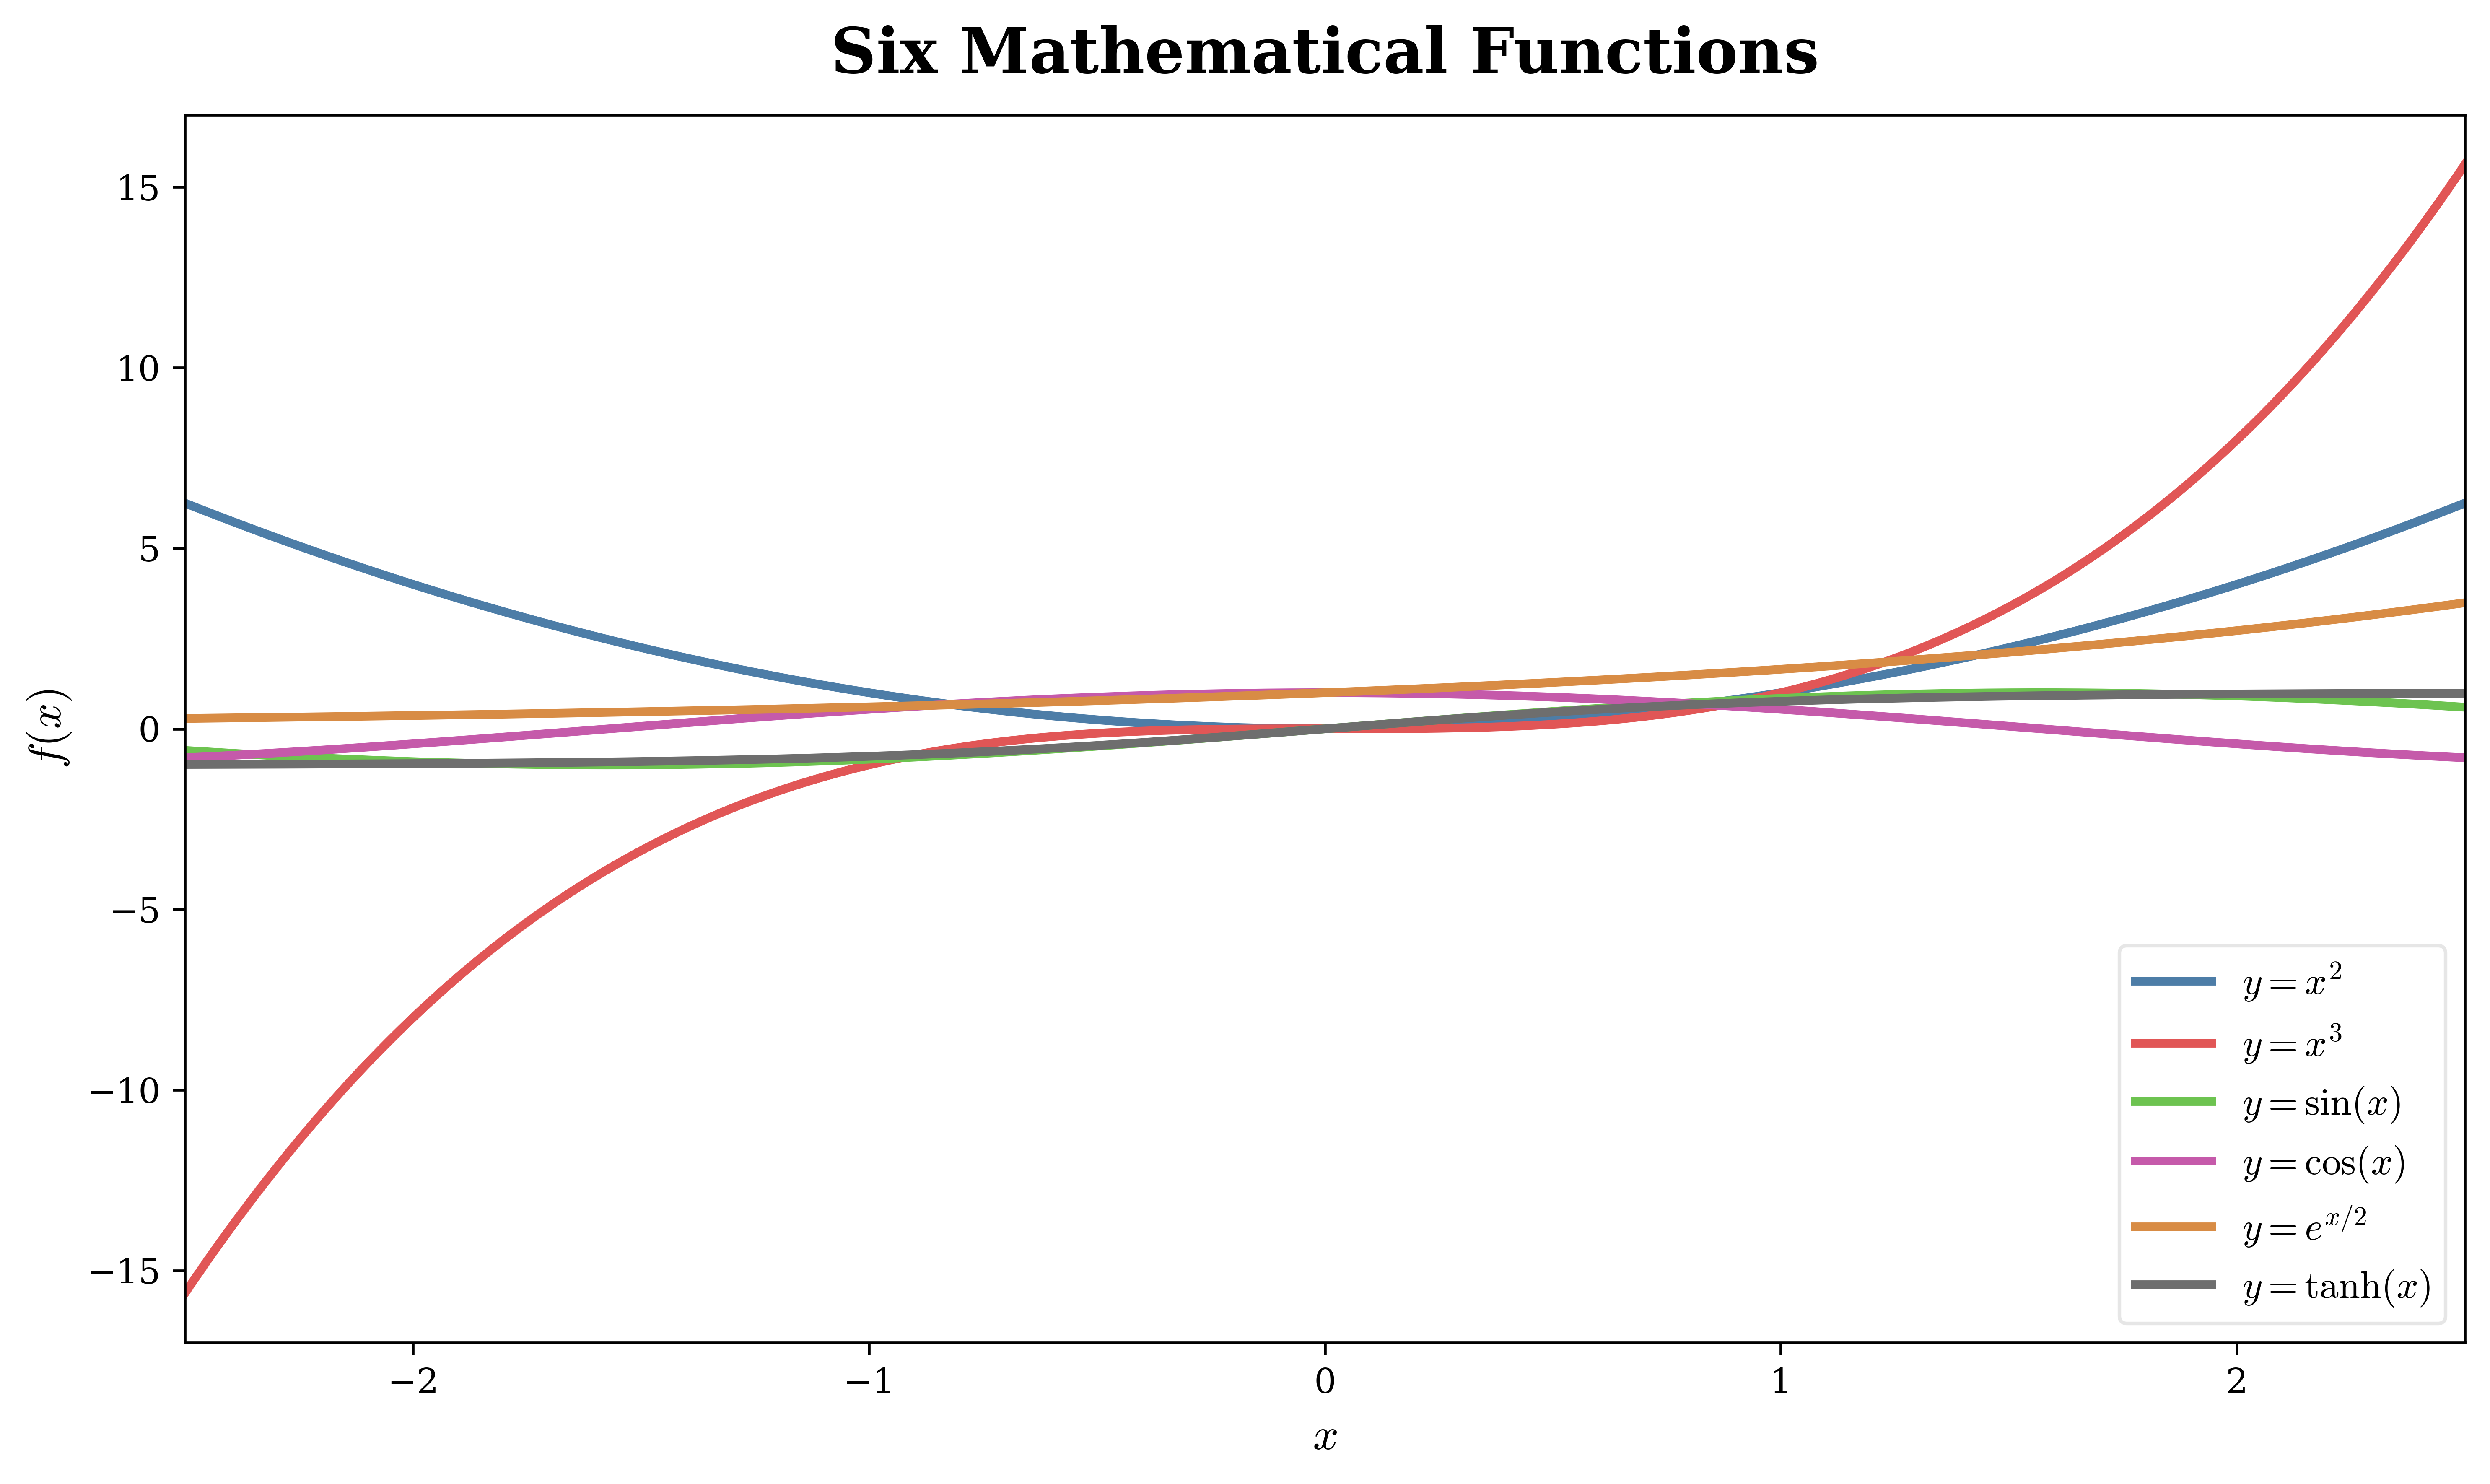

In [1]:
"""
Animated GIF of six mathematical functions.

Each curve is progressively drawn from left to right and saved as a GIF.
Requires Pillow:
    pip install pillow
"""

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation


# ---------------------------------------------------------------------
# Global plot configuration
# ---------------------------------------------------------------------
plt.rcParams["figure.dpi"] = 600
plt.rcParams["savefig.dpi"] = 600
plt.rcParams["mathtext.fontset"] = "cm"
plt.rcParams["font.family"] = "serif"


# ---------------------------------------------------------------------
# Custom colors
# ---------------------------------------------------------------------
niceblue = "#4d7da7"
nicered = "#e15656"
nicegreen = "#6dc350"
nicegray = "#6e6e6e"
nicemagenta = "#c55aaa"
niceorange = "#d88c45"


# ---------------------------------------------------------------------
# Animation settings
# ---------------------------------------------------------------------
save_gif = True
gif_filename = "six_mathematical_functions.gif"

n_frames = 180
frames_per_second = 30


# ---------------------------------------------------------------------
# Data
# ---------------------------------------------------------------------
x = np.linspace(-2.5, 2.5, 1000)

functions = [
    (x**2, niceblue, r"$y=x^2$"),
    (x**3, nicered, r"$y=x^3$"),
    (np.sin(x), nicegreen, r"$y=\sin(x)$"),
    (np.cos(x), nicemagenta, r"$y=\cos(x)$"),
    (np.exp(x / 2), niceorange, r"$y=e^{x/2}$"),
    (np.tanh(x), nicegray, r"$y=\tanh(x)$"),
]


# ---------------------------------------------------------------------
# Create figure
# ---------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 6))

ax.set_title("Six Mathematical Functions", fontsize=18, fontweight="bold", pad=12)
ax.set_xlabel(r"$x$", fontsize=13)
ax.set_ylabel(r"$f(x)$", fontsize=13)

ax.set_xlim(-2.5, 2.5)
ax.set_ylim(-17, 17)

ax.grid(False)

# Optional reference lines
# ax.axhline(0, color="black", linewidth=0.8, alpha=0.5)
# ax.axvline(0, color="black", linewidth=0.8, alpha=0.5)


# Create empty line objects.
lines = []

for _, color, label in functions:
    line, = ax.plot(
        [],
        [],
        color=color,
        linewidth=2.5,
        label=label,
    )
    lines.append(line)

ax.legend(
    loc="lower right",
    frameon=True,
    facecolor="white",
    edgecolor="#e0e0e0",
    fontsize=11,
)

fig.tight_layout()


# ---------------------------------------------------------------------
# Animation functions
# ---------------------------------------------------------------------
def initialize():
    """Start every curve as an empty line."""
    for line in lines:
        line.set_data([], [])

    return lines


def update(frame):
    """Reveal a larger portion of every mathematical function."""
    end_index = int((frame + 1) / n_frames * len(x))

    for line, (y, _, _) in zip(lines, functions):
        line.set_data(x[:end_index], y[:end_index])

    return lines


# ---------------------------------------------------------------------
# Build animation
# ---------------------------------------------------------------------
animated_plot = animation.FuncAnimation(
    fig,
    update,
    init_func=initialize,
    frames=n_frames,
    interval=1000 / frames_per_second,
    blit=True,
)


# ---------------------------------------------------------------------
# Save GIF
# ---------------------------------------------------------------------
if save_gif:
    gif_writer = animation.PillowWriter(fps=frames_per_second)

    animated_plot.save(
        gif_filename,
        writer=gif_writer,
        dpi=150,  # Keep GIF file size reasonable; 600 DPI would be massive.
    )

    print(f"GIF saved successfully: {gif_filename}")


plt.show()

In [ ]:
"""
Animated GIF with multiple annotation styles on y = sin(x).

Animation stages:
1. Draw the sine curve.
2. Shade its positive area.
3. Highlight one interval.
4. Show the maximum point.
5. Show a boxed callout with an arrow.

Install Pillow once if needed:
    pip install pillow
"""

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from matplotlib.patches import Patch


# ---------------------------------------------------------------------
# Global plot configuration
# ---------------------------------------------------------------------
plt.rcParams["figure.dpi"] = 600
plt.rcParams["savefig.dpi"] = 600
plt.rcParams["mathtext.fontset"] = "cm"
plt.rcParams["font.family"] = "serif"


# ---------------------------------------------------------------------
# Custom colors
# ---------------------------------------------------------------------
niceblue = "#4d7da7"
nicered = "#e15656"
nicegreen = "#6dc350"
nicegray = "#6e6e6e"
nicemagenta = "#c55aaa"
niceorange = "#d88c45"


# ---------------------------------------------------------------------
# Save settings
# ---------------------------------------------------------------------
save_gif = True
gif_filename = "annotated_sine_animation.gif"

frames_per_second = 25

# GIFs become extremely large at 600 DPI.
gif_dpi = 320


# ---------------------------------------------------------------------
# Data
# ---------------------------------------------------------------------
x = np.linspace(-2 * np.pi, 2 * np.pi, 1000)
y = np.sin(x)

# Interval to emphasize
interval_start = 1
interval_end = 3
selected_interval = (x >= interval_start) & (x <= interval_end)

# Maximum of y = sin(x)
maximum_x = np.pi / 2
maximum_y = 1


# ---------------------------------------------------------------------
# Figure and axes
# ---------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 6))

# These margins protect x/y labels in the GIF.
fig.subplots_adjust(
    left=0.13,
    bottom=0.15,
    right=0.97,
    top=0.89,
)

ax.set_title(
    r"Animated Annotations on $y=\sin(x)$",
    fontsize=18,
    fontweight="bold",
    pad=14,
)

ax.set_xlabel(r"$x$", fontsize=18, labelpad=10)
ax.set_ylabel(r"$y$", fontsize=18, labelpad=10)

ax.set_xlim(x.min(), x.max())
ax.set_ylim(-1.45, 1.60)

ax.grid(False)

ax.axhline(
    0,
    color=nicegray,
    linestyle="--",
    linewidth=1.0,
    alpha=0.75,
    zorder=0,
)


# ---------------------------------------------------------------------
# Empty artists that will be updated frame by frame
# ---------------------------------------------------------------------
main_line, = ax.plot(
    [],
    [],
    color=niceblue,
    linewidth=2.7,
    label=r"$y=\sin(x)$",
    zorder=3,
)

highlight_line, = ax.plot(
    [],
    [],
    color=nicered,
    linewidth=4.0,
    label=r"Highlighted interval: $1 \leq x \leq 3$",
    zorder=4,
)

maximum_point = ax.scatter(
    [],
    [],
    color=nicered,
    s=95,
    zorder=5,
)
maximum_point.set_visible(False)

interval_text = ax.text(
    1.55,
    -0.60,
    "Highlighted interval",
    color=nicered,
    fontsize=11,
    fontweight="bold",
)
interval_text.set_visible(False)

callout = ax.annotate(
    r"Maximum" + "\n" + r"$(\pi/2,\ 1)$",
    xy=(maximum_x, maximum_y),
    xytext=(2.55, 1.25),
    fontsize=11,
    color=nicegray,
    ha="left",
    va="center",
    bbox={
        "facecolor": "white",
        "edgecolor": niceblue,
        "boxstyle": "round,pad=0.45",
    },
    arrowprops={
        "arrowstyle": "->",
        "color": niceblue,
        "lw": 1.5,
    },
)
callout.set_visible(False)


# A proxy only for the legend because fill_between is created dynamically.
positive_area_proxy = Patch(
    facecolor=nicemagenta,
    alpha=0.25,
    label=r"Positive area: $y \geq 0$",
)

ax.legend(
    handles=[main_line, highlight_line, positive_area_proxy],
    loc="lower left",
    frameon=True,
    facecolor="white",
    edgecolor="#e0e0e0",
    fontsize=10,
)


# ---------------------------------------------------------------------
# Animation timeline
# ---------------------------------------------------------------------
stages = {
    "draw_curve": 100,
    "shade_area": 35,
    "highlight_interval": 35,
    "show_callout": 35,
}

n_frames = sum(stages.values())

artists = {
    "shade": None,
}


# ---------------------------------------------------------------------
# Animation functions
# ---------------------------------------------------------------------
def initialize():
    """Reset every animated object before the GIF begins."""
    main_line.set_data([], [])
    highlight_line.set_data([], [])

    maximum_point.set_visible(False)
    interval_text.set_visible(False)
    callout.set_visible(False)

    if artists["shade"] is not None:
        artists["shade"].remove()
        artists["shade"] = None

    return (
        main_line,
        highlight_line,
        maximum_point,
        interval_text,
        callout,
    )


def update(frame):
    """Update the plot for one GIF frame."""

    # Remove the old shaded region before drawing its new larger version.
    if artists["shade"] is not None:
        artists["shade"].remove()
        artists["shade"] = None

    # --------------------------------------------------------------
    # Stage 1: Draw y = sin(x) from left to right
    # --------------------------------------------------------------
    draw_progress = min(
        (frame + 1) / stages["draw_curve"],
        1,
    )

    draw_end = max(1, int(draw_progress * len(x)))

    main_line.set_data(
        x[:draw_end],
        y[:draw_end],
    )

    # --------------------------------------------------------------
    # Stage 2: Gradually reveal positive shaded area
    # --------------------------------------------------------------
    shade_start = stages["draw_curve"]

    shade_progress = np.clip(
        (frame - shade_start + 1) / stages["shade_area"],
        0,
        1,
    )

    if shade_progress > 0:
        shade_end = max(1, int(shade_progress * len(x)))

        artists["shade"] = ax.fill_between(
            x[:shade_end],
            0,
            y[:shade_end],
            where=y[:shade_end] >= 0,
            color=nicemagenta,
            alpha=0.25,
            zorder=1,
        )

    # --------------------------------------------------------------
    # Stage 3: Draw the highlighted red interval
    # --------------------------------------------------------------
    highlight_start = (
        stages["draw_curve"]
        + stages["shade_area"]
    )

    highlight_progress = np.clip(
        (frame - highlight_start + 1)
        / stages["highlight_interval"],
        0,
        1,
    )

    if highlight_progress > 0:
        visible_interval_end = (
            interval_start
            + highlight_progress * (interval_end - interval_start)
        )

        visible_interval = (
            selected_interval
            & (x <= visible_interval_end)
        )

        highlight_line.set_data(
            x[visible_interval],
            y[visible_interval],
        )

        interval_text.set_visible(True)

    else:
        highlight_line.set_data([], [])
        interval_text.set_visible(False)

    # --------------------------------------------------------------
    # Stage 4: Show maximum point and boxed arrow annotation
    # --------------------------------------------------------------
    callout_start = (
        highlight_start
        + stages["highlight_interval"]
    )

    show_callout = frame >= callout_start

    maximum_point.set_visible(show_callout)
    callout.set_visible(show_callout)

    if show_callout:
        maximum_point.set_offsets(
            np.array([[maximum_x, maximum_y]])
        )

    return (
        main_line,
        highlight_line,
        maximum_point,
        interval_text,
        callout,
    )


# ---------------------------------------------------------------------
# Create animation
# ---------------------------------------------------------------------
animated_plot = animation.FuncAnimation(
    fig,
    update,
    init_func=initialize,
    frames=n_frames,
    interval=1000 / frames_per_second,
    blit=False,
    repeat=True,
)


# ---------------------------------------------------------------------
# Save GIF
# ---------------------------------------------------------------------
if save_gif:
    gif_writer = animation.PillowWriter(
        fps=frames_per_second,
    )

    animated_plot.save(
        gif_filename,
        writer=gif_writer,
        dpi=gif_dpi,
    )

    print(f"GIF saved: {gif_filename}")


plt.show()